In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
from copy import deepcopy
from functools import partial

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from sklearn.metrics import auc
from tqdm import tqdm
from scipy.stats import spearmanr

from rebinding.efflux_model_collection import washout_zero_bound_extra_compartment
from rebinding.fig_utils import defaultStyle, save_fig
from rebinding.pd_expt import pd_data_processing, plot_cell_growth, plot_gr_curves

defaultStyle(fs=14)

# Load data

In [3]:
default_conc = np.concatenate([[1e-4], np.logspace(np.log10(0.003), np.log10(30), 9)])
alisertib_conc = np.concatenate([[1e-4], np.logspace(np.log10(0.01), np.log10(100), 9)])
ispinesib_conc = np.concatenate([[1e-4], np.logspace(np.log10(0.001), np.log10(1), 9)])

data_wash = pd.concat(
    [
        pd_data_processing(
            "../data/BYL237/939960DB_summary_positions_EC.xlsx",
            cpds=["PTX", "Alisertib", "VB"],
            drop_cpd="Alisertib",
            plate_idx=1,
        ),
        pd_data_processing(
            "../data/BYL239/9AA1D3E7_summary_positions_EC.xlsx",
            cpds=["Topotecan", "Colchicine", "Alisertib"],
            drop_cpd="Alisertib",
            plate_idx=2,
        ),
        pd_data_processing(
            "../data/BYL243/D39074DA_summary_positions_EC.xlsx",
            cpds=["Ispinesib", "PLN", "Alisertib"],
            concs=[ispinesib_conc, default_conc, alisertib_conc],
            plate_idx=3,
        ),
        pd_data_processing(
            "../data/BYL245/B374C68B_summary_positions_EC.xlsx",
            cpds=["Erlotinib", "Gefitinib", "CA4"],
            drop_cpd=["Erlotinib", "Gefitinib"],
            plate_idx=4,
        ),
    ]
).reset_index(drop=True)
data_no_wash = pd.concat(
    [
        pd_data_processing(
            "../data/BYL237/B4C07D7A_summary_positions_EC.xlsx",
            cpds=["PTX", "Alisertib", "VB"],
            drop_cpd="Alisertib",
            plate_idx=5,
        ),
        pd_data_processing(
            "../data/BYL239/DBE0D841_summary_positions_EC.xlsx",
            cpds=["Topotecan", "Colchicine", "Alisertib"],
            drop_cpd="Alisertib",
            plate_idx=6,
        ),
        pd_data_processing(
            "../data/BYL243/51B0A4FF_summary_positions_EC.xlsx",
            cpds=["Ispinesib", "PLN", "Alisertib"],
            concs=[ispinesib_conc, default_conc, alisertib_conc],
            plate_idx=7,
        ),
        pd_data_processing(
            "../data/BYL245/67CAF0B0_summary_positions_EC.xlsx",
            cpds=["Erlotinib", "Gefitinib", "CA4"],
            drop_cpd=["Erlotinib", "Gefitinib"],
            plate_idx=8,
        ),
    ]
).reset_index(drop=True)

# Filter data

In [4]:
data_no_wash["Wash"] = False
data_wash["Wash"] = True
data = pd.concat([data_no_wash, data_wash]).reset_index(drop=True)
data["lgc"] = data.c.apply(lambda x: np.log10(x * 1e4))

# Normalization

In [5]:
def pd_data_normalize_t(data):
    data_init = (
        data[data.t == 0][["abs_pos", "confluency"]]
        .groupby(["abs_pos"])
        .mean()
        .reset_index()
    )
    data["confluency_init"] = data.apply(
        lambda df: data_init.loc[data_init.abs_pos == df.abs_pos, "confluency"].values[
            0
        ],
        axis=1,
    )
    data["confluency_norm"] = data.confluency / data.confluency_init
    data_ctrl = (
        data[data.c == 1e-4][["confluency_norm", "plate", "t"]]
        .groupby(["plate", "t"])
        .mean()
        .reset_index()
    )
    data["confluency_norm_ctrl"] = data.apply(
        lambda df: data_ctrl.loc[
            (data_ctrl.plate == df.plate) & (data_ctrl.t == df.t),
            "confluency_norm",
        ].values[0],
        axis=1,
    )
    data["gr"] = data.apply(
        lambda df: 2 ** (np.log(df.confluency_norm) / np.log(df.confluency_norm_ctrl))
        - 1,
        axis=1,
    )


def time_dependent_gr(data):
    abs_pos_list = data.abs_pos.unique()
    abs_pos_to_growth_rate = {}
    for abs_pos in abs_pos_list:
        curr_data = data[data.abs_pos == abs_pos]
        curr_conf_data = savgol_filter(curr_data.confluency.values, 7, 1)
        data.loc[data.abs_pos == abs_pos, "confluency_smooth"] = curr_conf_data
        g_t = np.concatenate(
            [
                [curr_conf_data[1] / curr_conf_data[0]],
                curr_conf_data[2:] / curr_conf_data[:-2],
                [curr_conf_data[-1] / curr_conf_data[-2]],
            ]
        )
        data.loc[data.abs_pos == abs_pos, "g_t"] = g_t


def normalize_gr(data):
    # data_ctrl = (
    #     data[data.c == 1e-4][["g_t", "plate", "t"]]
    #     .groupby(["plate", "t"])
    #     .mean()
    #     .reset_index()
    # )
    g_t_ctrl = data[data.c == 1e-4].g_t.max()
    # data["g_t_ctrl"] = data.apply(
    #     lambda df: data_ctrl.loc[
    #         (data_ctrl.plate == df.plate) & (data_ctrl.t == df.t),
    #         "g_t",
    #     ].values[0],
    #     axis=1,
    # )
    data["gr_t"] = data.apply(
        lambda df: 2 ** (np.log(df.g_t) / np.log(g_t_ctrl)) - 1,
        axis=1,
    )


pd_data_normalize_t(data)
time_dependent_gr(data)
normalize_gr(data)

/tmp/ipykernel_28429/1013414568.py:29: RuntimeWarning: invalid value encountered in scalar divide
  lambda df: 2 ** (np.log(df.confluency_norm) / np.log(df.confluency_norm_ctrl))


# Plot

100%|██████████████████████████████████████████████| 7/7 [00:01<00:00,  4.40it/s]
/home/liboyan/Documents/Research/rebind/rebinding2025/code/rebinding/fig_utils.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saving figure figSupp3_growth_curves


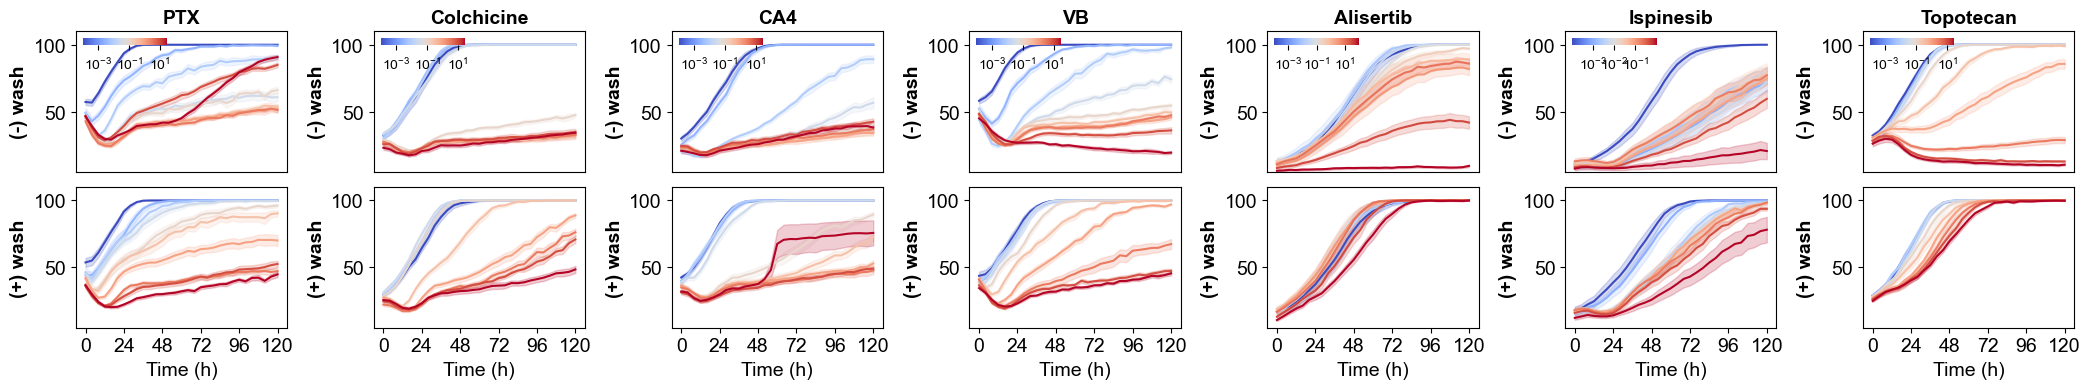

In [6]:
cpds = ["PTX", "Colchicine", "CA4", "VB", "Alisertib", "Ispinesib", "Topotecan"]

_, axes = plt.subplots(2, len(cpds), figsize=(3 * len(cpds), 4))
plt.subplots_adjust(hspace=0.0, wspace=0.0)
for i, cpd in enumerate(tqdm(cpds)):
    curr_ax = axes[:, i]
    cbar_ticks = [1, 2, 3] if cpd == "Ispinesib" else [1, 3, 5]
    cbar_ticklabels = (
        [r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$"]
        if cpd == "Ispinesib"
        else [r"$10^{-3}$", r"$10^{-1}$", r"$10^1$"]
    )
    plot_cell_growth(
        cpd, data, axes=curr_ax, cbar_ticks=cbar_ticks, cbar_ticklabels=cbar_ticklabels
    )
    for bx in curr_ax:
        bx.set_xlabel("")
        bx.set_ylabel("")
    curr_ax[0].set_title(cpd, fontsize=14, fontweight="bold")
    curr_ax[1].set_title("")
    for bx in curr_ax:
        """
        bx.tick_params(
            axis="x",
            which="both",
            bottom=False,
            labelbottom=False,
        )
        bx.tick_params(
            axis="y",
            which="both",
            left=False,
            labelleft=False,
        )
        """
        bx.set_xticks([24 * i for i in range(6)])
        bx.set_ylim([5, 110])
    curr_ax[0].set_ylabel("(-) wash", fontsize=14, fontweight="bold")
    curr_ax[1].set_ylabel("(+) wash", fontsize=14, fontweight="bold")
    curr_ax[1].set_xlabel("Time (h)", fontsize=14)
    curr_ax[0].tick_params(
        axis="x",
        which="both",
        bottom=False,
        labelbottom=False,
    )
save_fig(f"figSupp3_growth_curves", fmt="png", dpi=300)

# GR index dose response

In [7]:
def dose_response_curve(lgc, gmin, gmax, lg_gi50, n):
    gmed = (gmin + gmax) / 2
    y = gmin + (gmax - gmin) / (1 + (lgc / lg_gi50) ** n)
    return y


def fit_response_curves(lgc, gmin, gmax, lg_gi50_1, lg_gi50_2, n1, n2):
    cut_idx = np.where(lgc[1:] < lgc[:-1] - 1)[0][0] + 1
    curve_1 = dose_response_curve(lgc[:cut_idx], gmin, gmax, lg_gi50_1, n1)
    curve_2 = dose_response_curve(lgc[cut_idx:], gmin, gmax, lg_gi50_2, n2)
    return np.concatenate([curve_1, curve_2])

 86%|███████████████████████████████████████▍      | 6/7 [00:00<00:00,  9.29it/s]

[ 0.9190547   1.58161456  1.99984462 20.        ] [ 0.9190547  1.4267328 30.        20.       ]
[ 0.05214239  0.95734928  5.63101372 20.        ] [ 0.05214239  1.11961149 30.         20.        ]
[ 0.04140648  0.89135946  5.57490767 20.        ] [ 0.04140648  0.98425051 30.         20.        ]


100%|██████████████████████████████████████████████| 7/7 [00:00<00:00,  9.27it/s]


Saving figure figSupp3_gr_dose


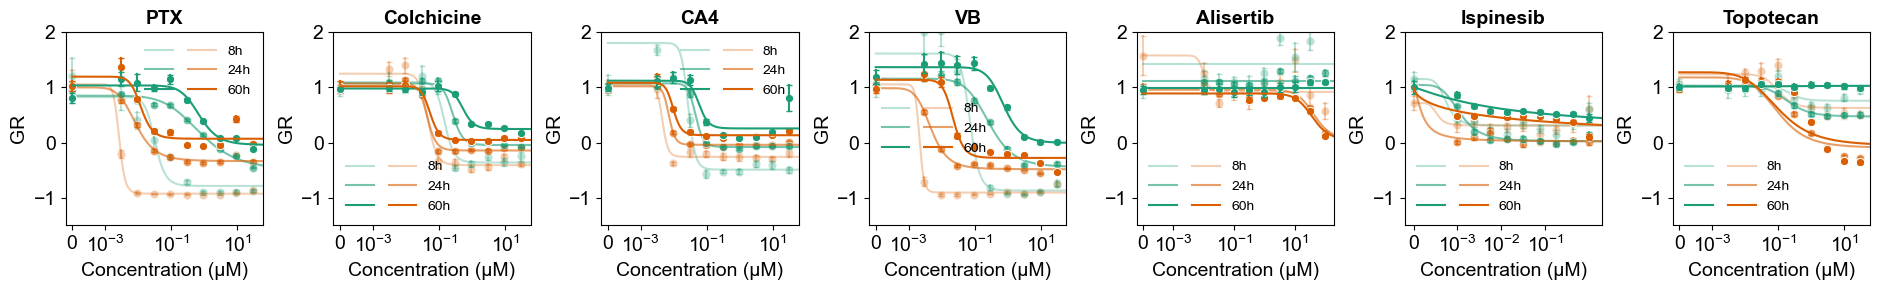

In [8]:
colors = plt.cm.Dark2.colors

# cpds = ["PTX", "DTX", "Colchicine", "CA4", "VB"] # , "Alisertib", "Ispinesib", "Topotecan"]
cpds = ["PTX", "Colchicine", "CA4", "VB", "Alisertib", "Ispinesib", "Topotecan"]
_, ax = plt.subplots(1, len(cpds), figsize=(len(cpds) * 2.7, 3))
plt.subplots_adjust(wspace=0.02, hspace=0.02)
if len(cpds) == 1:
    ax = np.array([ax])
line_props = {
    "linestyle": "",
    "marker": "o",
    "markersize": 6,
    "err_style": "bars",
    "errorbar": "se",
    "err_kws": {"capsize": 2},
}
p0_arr = np.array(
    [
        [0, 1, 1, 2],
        [0, 1, 1, 2],
        [0, 1, 1, 2],
        [0, 1, 1, 2],
        [0, 0.8, 6, 1],
        [0, 1, 0.3, 2],
        [0, 1, 3, 1],
    ]
)
y = "gr"
for i, cpd in enumerate(tqdm(cpds)):
    curr_ax = ax[i]
    for j, t_ref in enumerate([8, 24, 60]):
        alpha = [0.3, 0.6, 1][j]
        plot_gr_curves(
            cpd,
            data,
            t_ref=t_ref,
            ax=curr_ax,
            line_props=line_props,
            dose_res_y=y,
            colors=colors[1::-1],
            alpha=alpha,
        )
        curr_data = data[(data.cpd == cpd) & (data.t == t_ref)]
        curr_data = curr_data.sort_values(by=["Wash", "lgc"]).reset_index(drop=True)

        gmin_bound = curr_data[y].min()
        bounds_l = [gmin_bound, 0.5, 0.2, 0.3]
        bounds_h = [np.inf] * 4
        bounds_h[2] = 7 if cpd == "Alisertib" else 3
        bounds_h[3] = 20

        gmin_guess = curr_data[y].min()
        gmax_guess = curr_data[y].max()
        p0 = [gmin_guess, gmax_guess, p0_arr[i][2], p0_arr[i][3]]
        params_1 = curve_fit(
            dose_response_curve,
            curr_data[np.logical_not(curr_data.Wash)].lgc.values,
            curr_data[np.logical_not(curr_data.Wash)][y].values,
            p0=p0,
            method="dogbox",
            bounds=[bounds_l, bounds_h],
        )[0]
        gmin, gmax = params_1[:2]

        p0_2 = deepcopy(params_1)
        if cpd == "Alisertib":
            p0_2[2] = 30
        params_2 = curve_fit(
            dose_response_curve,
            curr_data[curr_data.Wash].lgc.values,
            curr_data[curr_data.Wash][y].values,
            p0=p0_2,
            method="dogbox",
            bounds=[
                [gmin_guess, 0.5, params_1[2], max(0.3, params_1[3])],
                [np.inf, np.inf, np.inf, params_1[3] + 3],
            ],
        )[0]
        if cpd == "Alisertib":
            print(params_1, params_2)
        x = np.linspace(0, 8, 1000)
        curr_ax.plot(
            x,
            dose_response_curve(x, *params_2),
            color=colors[0],
            alpha=alpha,
            label=" ",
        )
        curr_ax.plot(
            x,
            dose_response_curve(x, *params_1),
            color=colors[1],
            alpha=alpha,
            label=f"{t_ref}h",
        )
        curr_ax.set_ylim([-1.5, 2])
        curr_ax.set_xlim([-0.2, curr_data.lgc.max() + 0.3])
        curr_ax.set_xlabel("")
        curr_ax.set_ylabel("")
        xticks = range(4) if cpd == "Ispinesib" else [0, 1, 3, 5]
        xticklabels = (
            [0, r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$"]
            if cpd == "Ispinesib"
            else [0, r"$10^{-3}$", r"$10^{-1}$", r"$10^1$"]
        )
        curr_ax.set_xticks(xticks)
        curr_ax.set_xticklabels(xticklabels)
        curr_ax.set_xlabel("Concentration (μM)")
        curr_ax.set_ylabel("GR")
        if j == 0:
            ax[i].set_title(cpd, fontsize=14, fontweight="bold")
    handles, labels = curr_ax.get_legend_handles_labels()
    order = [0, 2, 4, 1, 3, 5]
    curr_ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        ncols=2,
        columnspacing=0.0,
        frameon=False,
    )
save_fig("figSupp3_gr_dose", fmt="png", dpi=300)

# GR DRAUC

100%|███████████████████████████████████████████| 19/19 [00:00<00:00, 241.83it/s]


Saving figure figSupp5_DRAUC


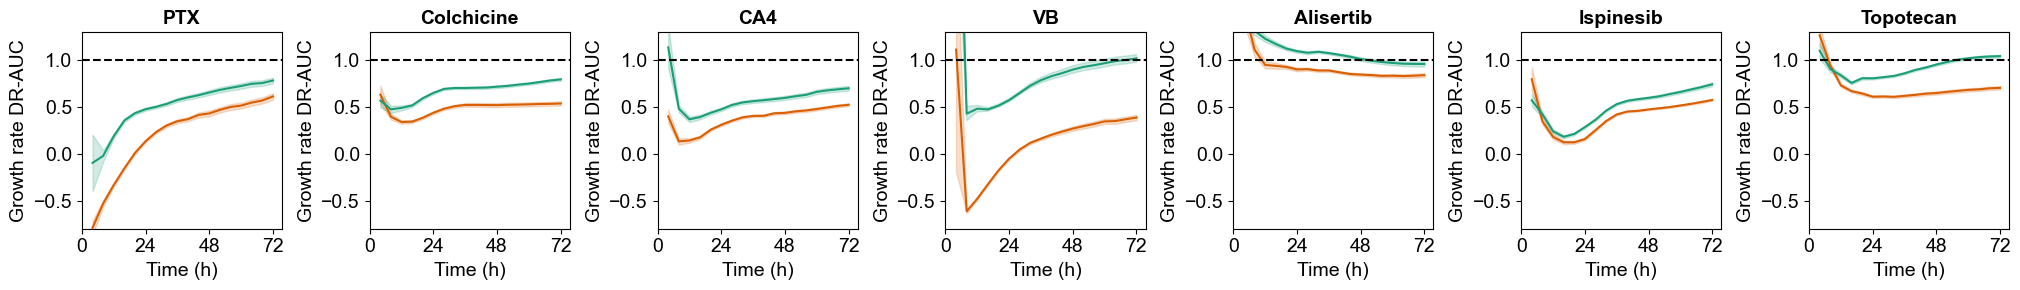

In [10]:
colors = plt.cm.Dark2.colors

# drugs = ["DTX", "Alisertib", "Ispinesib"]
drugs = ["PTX", "Colchicine", "CA4", "VB", "Alisertib", "Ispinesib", "Topotecan"]
y = "gr"

_, ax = plt.subplots(1, len(drugs), figsize=(2.9 * len(drugs), 3))
plt.subplots_adjust(wspace=0.02)
drug_aucs = {}
for i, drug in enumerate(drugs):
    drug_data = data[data.cpd == drug][["lgc", y, "t", "Wash"]]
    params_dict = {}
    tlist = drug_data.t.unique()
    tlist = tlist[(tlist >= 0) & (tlist <= 72)]
    aucs = []
    for t in tqdm(tlist):
        curr_data = drug_data[drug_data.t == t]
        curr_data_std = curr_data.groupby(["Wash", "lgc"]).sem(ddof=0).reset_index()
        curr_data = curr_data.groupby(["Wash", "lgc"]).mean().reset_index()
        curr_auc = []
        for wash in [False, True]:
            df = curr_data[curr_data.Wash == wash]
            df_std = curr_data_std[curr_data_std.Wash == wash]
            lgc_minmax = df.lgc.max() - df.lgc.min()
            a = auc(df.lgc, df[y]) / lgc_minmax
            w = np.diff(df.lgc.values / lgc_minmax).tolist()
            w = np.array([0] + w + [0])
            w = 0.5 * (w[1:] + w[:-1])
            se = np.sum(((w * df_std[y].values) ** 2)) ** 0.5
            curr_auc += [a, se]
        aucs.append(curr_auc)
    aucs = np.array(aucs)
    drug_aucs[drug] = aucs
    ax[i].plot(tlist, aucs[:, 0], color=colors[1])
    ax[i].fill_between(
        tlist,
        aucs[:, 0] + aucs[:, 1],
        aucs[:, 0] - aucs[:, 1],
        alpha=0.2,
        color=colors[1],
    )
    ax[i].plot(tlist, aucs[:, 2], color=colors[0])
    ax[i].fill_between(
        tlist,
        aucs[:, 2] + aucs[:, 3],
        aucs[:, 2] - aucs[:, 3],
        alpha=0.2,
        color=colors[0],
    )
    ax[i].set_ylim(-0.8, 1.3)
    ax[i].set_xticks([24 * i for i in range(4)])
    # ax[i].set_title(drug, fontsize=14, fontweight="bold")
    ax[i].axhline(1, ls="--", c="k")
    ax[i].set_ylabel("Growth rate DR-AUC")
    ax[i].set_xlabel("Time (h)")
    ax[i].set_title(drug, fontsize=14, fontweight="bold")
# ax[1][0].set_ylabel(r"$GR_{\mathrm{max}}$")
save_fig("figSupp5_DRAUC", fmt="png", dpi=300)